# Homework 116

In [1]:
import tensorflow as tf
import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train = X_train.reshape(*X_train.shape, 1)
X_valid = X_valid.reshape(*X_valid.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)

## Task 1

да се тестват layer-ите поотделно
в оригиналния пример с Keras да се смени само 1 layer с нашата имплементация докато се настрои и бързодействието започне да доближава това на оригиналния модел. така да се тествт conv и pooling layer-ите

In [4]:
keras_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train.shape[1:]),

    tf.keras.layers.Conv2D(filters=32, kernel_size=3,
                           activation='relu',
                           kernel_initializer='he_normal'),

    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(10, activation='softmax')
])

keras_cnn.compile(loss='sparse_categorical_crossentropy',
            optimizer='adam', metrics=['accuracy'])

In [5]:
s = time.time()

keras_cnn.fit(X_train, y_train, epochs=10,
        validation_data=(X_valid, y_valid))

keras_fittime = time.time() - s

keras_loss, keras_acc = keras_cnn.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.8007 - loss: 0.5824 - val_accuracy: 0.8942 - val_loss: 0.2931
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.8980 - loss: 0.2849 - val_accuracy: 0.9022 - val_loss: 0.2729
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9154 - loss: 0.2341 - val_accuracy: 0.9056 - val_loss: 0.2586
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9260 - loss: 0.2019 - val_accuracy: 0.9070 - val_loss: 0.2549
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.9334 - loss: 0.1831 - val_accuracy: 0.9150 - val_loss: 0.2555
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9428 - loss: 0.1560 - val_accuracy: 0.9120 - val_loss: 0.2594
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9501 - loss: 0.1386 - val_accuracy: 0.9138 - val_loss: 0.2555
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9539 -

In [6]:
keras_fittime, keras_loss, keras_acc

(57.80905818939209, 0.36136412620544434, 0.9064000248908997)

In [10]:
keras_fittime = 53.15801644325256
keras_loss = 0.3174522817134857
keras_acc = 0.9081000089645386

In [6]:
class CustomConv2D(tf.keras.Layer):
    def __init__(self, filters, kernel_size, strides=(1, 1), padding='valid',
                 activation=None, kernel_initializer='glorot_uniform', **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.padding = padding
        self.activation = tf.keras.activations.get(activation)
        self.kernel_initializer = tf.keras.initializers.get(kernel_initializer)

        if not isinstance(kernel_size, tuple):
            kernel_size = (kernel_size, kernel_size)

        assert len(kernel_size) == 2, 'Invalid kernel_size'
        self.kernel_size = kernel_size

        if not isinstance(strides, tuple):
            strides = (strides, strides)

        assert len(strides) == 2, 'Invalid strides'
        self.strides = strides

    def _calc_output_shape(self, input):
        match self.padding:
            case 'valid':
                H_out = tf.cast(tf.math.floor((input[0] - self.kernel_size[0]) / self.strides[0]) + 1, tf.int32)
                W_out = tf.cast(tf.math.floor((input[1] - self.kernel_size[1]) / self.strides[1]) + 1, tf.int32)
            case 'same':
                H_out = tf.cast(tf.math.ceil(input[0] / self.strides[0]), tf.int32)
                W_out = tf.cast(tf.math.ceil(input[1] / self.strides[1]), tf.int32)
            case _:
                raise ValueError(f'Invalid padding: {self.padding}; expects: valid/same')

        self.output_shape = [H_out, W_out, self.filters]

    def build(self, input_shape):
        C_in = input_shape[-1]

        self.kernel = self.add_weight(name="kernel",
                                    shape=(*self.kernel_size, C_in, self.filters),
                                    initializer=self.kernel_initializer)

        self.bias = self.add_weight(name="bias",
                                shape=(self.filters,),
                                initializer="zeros")

        self._calc_output_shape(input_shape[1:])

    @tf.function
    def _calc(self, X):
        H_out, W_out, C_out = self.output_shape
        B_in, C_in = tf.shape(X)[0], tf.shape(X)[-1]

        patches = tf.image.extract_patches(
            images=X,
            sizes=[1, *self.kernel_size, 1],
            strides=[1, *self.strides, 1],
            rates=[1, 1, 1, 1],
            padding=self.padding.upper()
        )

        kernel_prod  = tf.reduce_prod(self.kernel_size)
        patches_flat = tf.reshape(patches, [B_in * H_out * W_out, kernel_prod * C_in])
        weights_flat = tf.reshape(self.kernel, [kernel_prod * C_in, C_out])
        out_flat     = tf.matmul(patches_flat, weights_flat) + self.bias
        out          = tf.reshape(out_flat, [B_in, H_out, W_out, C_out])
        return self.activation(out)

    def call(self, X, *_):
        if len(X.shape) < 3:
            raise ValueError('Conv2D except 3D inputs')

        return self._calc(X)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "strides": self.strides,
            "padding": self.padding,
            "output":  self.output_shape,
            "activation": tf.keras.activations.serialize(self.activation),
            "kernel_initializer": tf.keras.initializers.serialize(self.kernel_initializer),
        })
        return config

In [7]:
custom_conv_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train.shape[1:]),

    CustomConv2D(filters=32, kernel_size=3,
                activation='relu',
                kernel_initializer='he_normal'),

    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(10, activation='softmax')
])

custom_conv_cnn.compile(loss='sparse_categorical_crossentropy',
            optimizer='adam', metrics=['accuracy'])

In [8]:
s = time.time()

custom_conv_cnn.fit(X_train, y_train, epochs=10,
        validation_data=(X_valid, y_valid))

custom_conv_cnn_fittime = time.time() - s

custom_conv_cnn_loss, custom_conv_cnn_acc = custom_conv_cnn.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.8183 - loss: 0.5210 - val_accuracy: 0.8950 - val_loss: 0.2937
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.9062 - loss: 0.2646 - val_accuracy: 0.8984 - val_loss: 0.2821
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.9205 - loss: 0.2171 - val_accuracy: 0.9012 - val_loss: 0.2680
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9328 - loss: 0.1821 - val_accuracy: 0.9116 - val_loss: 0.2593
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9426 - loss: 0.1554 - val_accuracy: 0.9138 - val_loss: 0.2520
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9500 - loss: 0.1367 - val_accuracy: 0.9170 - val_loss: 0.2668
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.9575 - loss: 0.1177 - val_accuracy: 0.9180 - val_loss: 0.2649
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.9623 -

In [ ]:
custom_conv_cnn_fittime, custom_conv_cnn_loss, custom_conv_cnn_acc

In [9]:
custom_conv_cnn_fittime = 57.57092022895813
custom_conv_cnn_loss = 0.32156485319137573
custom_conv_cnn_acc = 0.9111999869346619

In [9]:
class CustomMaxPool2D(tf.keras.Layer):
    def __init__(self, pool_size=(2, 2), strides=None, padding='valid', **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size
        self.padding = padding

        if strides is None:
            strides = pool_size

        self.strides = strides
        self.kernel_size = pool_size

    def _calc_output_shape(self, input):
        match self.padding:
            case 'valid':
                H_out = tf.cast(tf.math.floor((input[0] - self.kernel_size[0]) / self.strides[0]) + 1, tf.int32)
                W_out = tf.cast(tf.math.floor((input[1] - self.kernel_size[1]) / self.strides[1]) + 1, tf.int32)
            case 'same':
                H_out = tf.cast(tf.math.ceil(input[0] / self.strides[0]), tf.int32)
                W_out = tf.cast(tf.math.ceil(input[1] / self.strides[1]), tf.int32)
            case _:
                raise ValueError(f'Invalid padding: {self.padding}; expects: valid/same')

        self.output_shape = [H_out, W_out, input[-1]]

    def build(self, input_shape):
        self._calc_output_shape(input_shape[1:])

    @tf.function
    def _calc(self, X):
        H_out, W_out, C_out = self.output_shape
        B_in, C_in = tf.shape(X)[0], tf.shape(X)[-1]

        patches = tf.image.extract_patches(
            images=X,
            sizes=[1, *self.kernel_size, 1],
            strides=[1, *self.strides, 1],
            rates=[1, 1, 1, 1],
            padding=self.padding.upper()
        )

        kernel_prod  = tf.reduce_prod(self.kernel_size)
        patches_reshaped = tf.reshape(patches, [B_in, H_out, W_out, kernel_prod, C_in])
        return tf.reduce_max(patches_reshaped, axis=3)

    def call(self, X, *_):
        if len(X.shape) < 3:
            raise ValueError('Conv2D except 3D inputs')

        return self._calc(X)

    def get_config(self):
        config = super().get_config()
        config.update({
            "kernel_size": self.kernel_size,
            "strides": self.strides,
            "padding": self.padding,
            "output":  self.output_shape,
        })
        return config

In [10]:
custom_maxpool_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train.shape[1:]),

    tf.keras.layers.Conv2D(filters=32, kernel_size=3,
                activation='relu',
                kernel_initializer='he_normal'),

    CustomMaxPool2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(10, activation='softmax')
])

custom_maxpool_cnn.compile(loss='sparse_categorical_crossentropy',
            optimizer='adam', metrics=['accuracy'])

In [11]:
s = time.time()

custom_maxpool_cnn.fit(X_train, y_train, epochs=10,
        validation_data=(X_valid, y_valid))

custom_maxpool_cnn_fittime = time.time() - s

custom_maxpool_cnn_loss, custom_maxpool_cnn_acc = custom_maxpool_cnn.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.8143 - loss: 0.5234 - val_accuracy: 0.8866 - val_loss: 0.3075
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.9032 - loss: 0.2676 - val_accuracy: 0.9058 - val_loss: 0.2619
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.9190 - loss: 0.2202 - val_accuracy: 0.9058 - val_loss: 0.2588
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9284 - loss: 0.1922 - val_accuracy: 0.9070 - val_loss: 0.2689
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9368 - loss: 0.1669 - val_accuracy: 0.9132 - val_loss: 0.2483
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.9460 - loss: 0.1437 - val_accuracy: 0.9082 - val_loss: 0.2750
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.9518 - loss: 0.1296 - val_accuracy: 0.9056 - val_loss: 0.2840
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 83s 25ms/step - accuracy: 0.9575 -

In [ ]:
custom_maxpool_cnn_fittime, custom_maxpool_cnn_loss, custom_maxpool_cnn_acc

In [8]:
custom_maxpool_cnn_fittime = 457.4202058315277
custom_maxpool_cnn_loss = 0.31709814071655273
custom_maxpool_cnn_acc = 0.911300003528595

In [12]:
custom_conv_maxpool_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train.shape[1:]),

    CustomConv2D(filters=32, kernel_size=3,
                activation='relu',
                kernel_initializer='he_normal'),

    CustomMaxPool2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(10, activation='softmax')
])

custom_conv_maxpool_cnn.compile(loss='sparse_categorical_crossentropy',
            optimizer='adam', metrics=['accuracy'])

In [13]:
s = time.time()

custom_conv_maxpool_cnn.fit(X_train, y_train, epochs=10,
        validation_data=(X_valid, y_valid))

custom_conv_maxpool_cnn_fittime = time.time() - s

custom_conv_maxpool_cnn_loss, custom_conv_maxpool_cnn_acc = custom_conv_maxpool_cnn.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.8095 - loss: 0.5302 - val_accuracy: 0.8782 - val_loss: 0.3260
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.8987 - loss: 0.2775 - val_accuracy: 0.9046 - val_loss: 0.2673
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9161 - loss: 0.2271 - val_accuracy: 0.9108 - val_loss: 0.2553
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9292 - loss: 0.1900 - val_accuracy: 0.9156 - val_loss: 0.2423
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - accuracy: 0.9352 - loss: 0.1733 - val_accuracy: 0.9160 - val_loss: 0.2489
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.9456 - loss: 0.1499 - val_accuracy: 0.9104 - val_loss: 0.2599
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.9510 - loss: 0.1313 - val_accuracy: 0.9130 - val_loss: 0.2706
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9585 -

In [14]:
rows = ['keras', 'custom Conv', 'custom MaxPool', 'custom Conv & MaxPool']
cols = ['Fit Time', 'ACC', 'Loss']

custom_conv_maxpool_cnn_fittime = time.time() - s

custom_conv_maxpool_cnn_loss, custom_conv_maxpool_cnn_acc

data = [
    [keras_fittime, keras_acc, keras_loss],
    [custom_conv_cnn_fittime, custom_conv_cnn_acc, custom_conv_cnn_loss],
    [custom_maxpool_cnn_fittime, custom_maxpool_cnn_acc, custom_maxpool_cnn_loss],
    [custom_conv_maxpool_cnn_fittime, custom_conv_maxpool_cnn_acc, custom_conv_maxpool_cnn_loss],
]

task1_res = pd.DataFrame(data, index=rows, columns=cols)
task1_res

,Fit Time,ACC,Loss
keras,362.757250,0.9100,0.306542
custom Conv,410.052477,0.9122,0.312938
custom MaxPool,514.598802,0.9097,0.315905
custom Conv & MaxPool,593.648313,0.9117,0.306877


## Task 3

In [6]:
from functools import partial
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                                activation="relu", kernel_initializer="he_normal")

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train.shape[1:]),
    DefaultConv2D(filters=64, kernel_size=7),
    tf.keras.layers.MaxPool2D(),

    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),

    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(units=64, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

model.compile(loss='sparse_categorical_crossentropy',
            optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=32,
        validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.5503 - loss: 1.2400 - val_accuracy: 0.8610 - val_loss: 0.4032
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8433 - loss: 0.4679 - val_accuracy: 0.8830 - val_loss: 0.3011
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8734 - loss: 0.3808 - val_accuracy: 0.8896 - val_loss: 0.2984
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8902 - loss: 0.3246 - val_accuracy: 0.8956 - val_loss: 0.2813
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8990 - loss: 0.3015 - val_accuracy: 0.9062 - val_loss: 0.2745
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9055 - loss: 0.2804 - val_accuracy: 0.9036 - val_loss: 0.2714
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9102 - loss: 0.2624 - val_accuracy: 0.9090 - val_loss: 0.2719
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9157 - loss: 

In [24]:
model.layers[0].filters

64

In [37]:
def max_activation_part(img, conv_layer, n_maps=10):
  img_r = tf.reshape(img, [1, *img.shape])
  maps = conv_layer(img_r)

  fig, ax = plt.subplots(1, n_maps, figsize=(14, 4))

  inxs = np.random.choice(conv_layer.filters, n_maps, False)
  for i, inx in enumerate(inxs):
    map = maps[0, :, :, inx].numpy()
    row, col = np.unravel_index(np.argmax(map), map.shape)

    v = conv_layer.kernel_size[0] // 2
    h = conv_layer.kernel_size[1] // 2
    img_cut = img[row-v : row+v, col-h : col+h]
    ax[i].imshow(img_cut)
    ax[i].axis('off')

  plt.show()


In [51]:
def max_activation_part_multi(imgs, conv_layer, n_maps=10):
  maps = conv_layer(imgs)
  fig, ax = plt.subplots(maps.shape[0], n_maps + 1, figsize=(14, 20))

  for i in range(maps.shape[0]):
    fmap_i = maps[i]
    maps_max = tf.reduce_max(fmap_i, axis=(0, 1))
    top_values, top_inxs = tf.math.top_k(maps_max, k=n_maps)
    top_inxs = top_inxs.numpy()

    ax[i, 0].imshow(imgs[i])
    ax[i, 0].axis('off')

    rows = []
    cols = []

    for j, inx in enumerate(top_inxs, start=1):
      fmap = fmap_i[:, :, inx].numpy()
      row, col = np.unravel_index(np.argmax(fmap), fmap.shape)

      rows.append(row)
      cols.append(col)

      v = conv_layer.kernel_size[0] // 2
      h = conv_layer.kernel_size[1] // 2

      img_cut = img[row-v : row+v, col-h : col+h]

      ax[i, j].imshow(img_cut)
      ax[i, j].axis('off')

    ax[i, 0].scatter(x=cols, y=rows, c='r')

  plt.show()

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

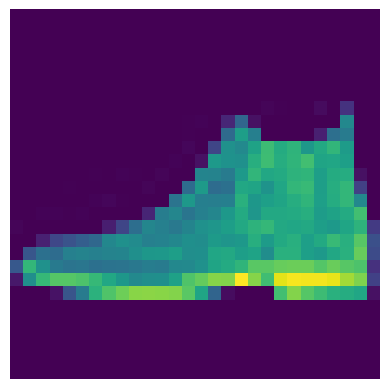

In [32]:
img = X_test[0]
plt.imshow(img)
plt.axis('off')

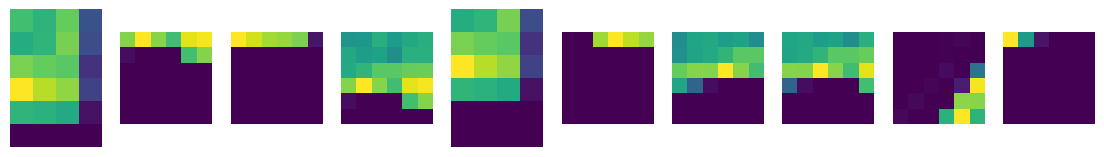

In [38]:
max_activation_part(img, model.layers[0])

/tmp/ipython-input-2460063579.py:29: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax[i, j].imshow(img_cut)
/tmp/ipython-input-2460063579.py:29: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax[i, j].imshow(img_cut)


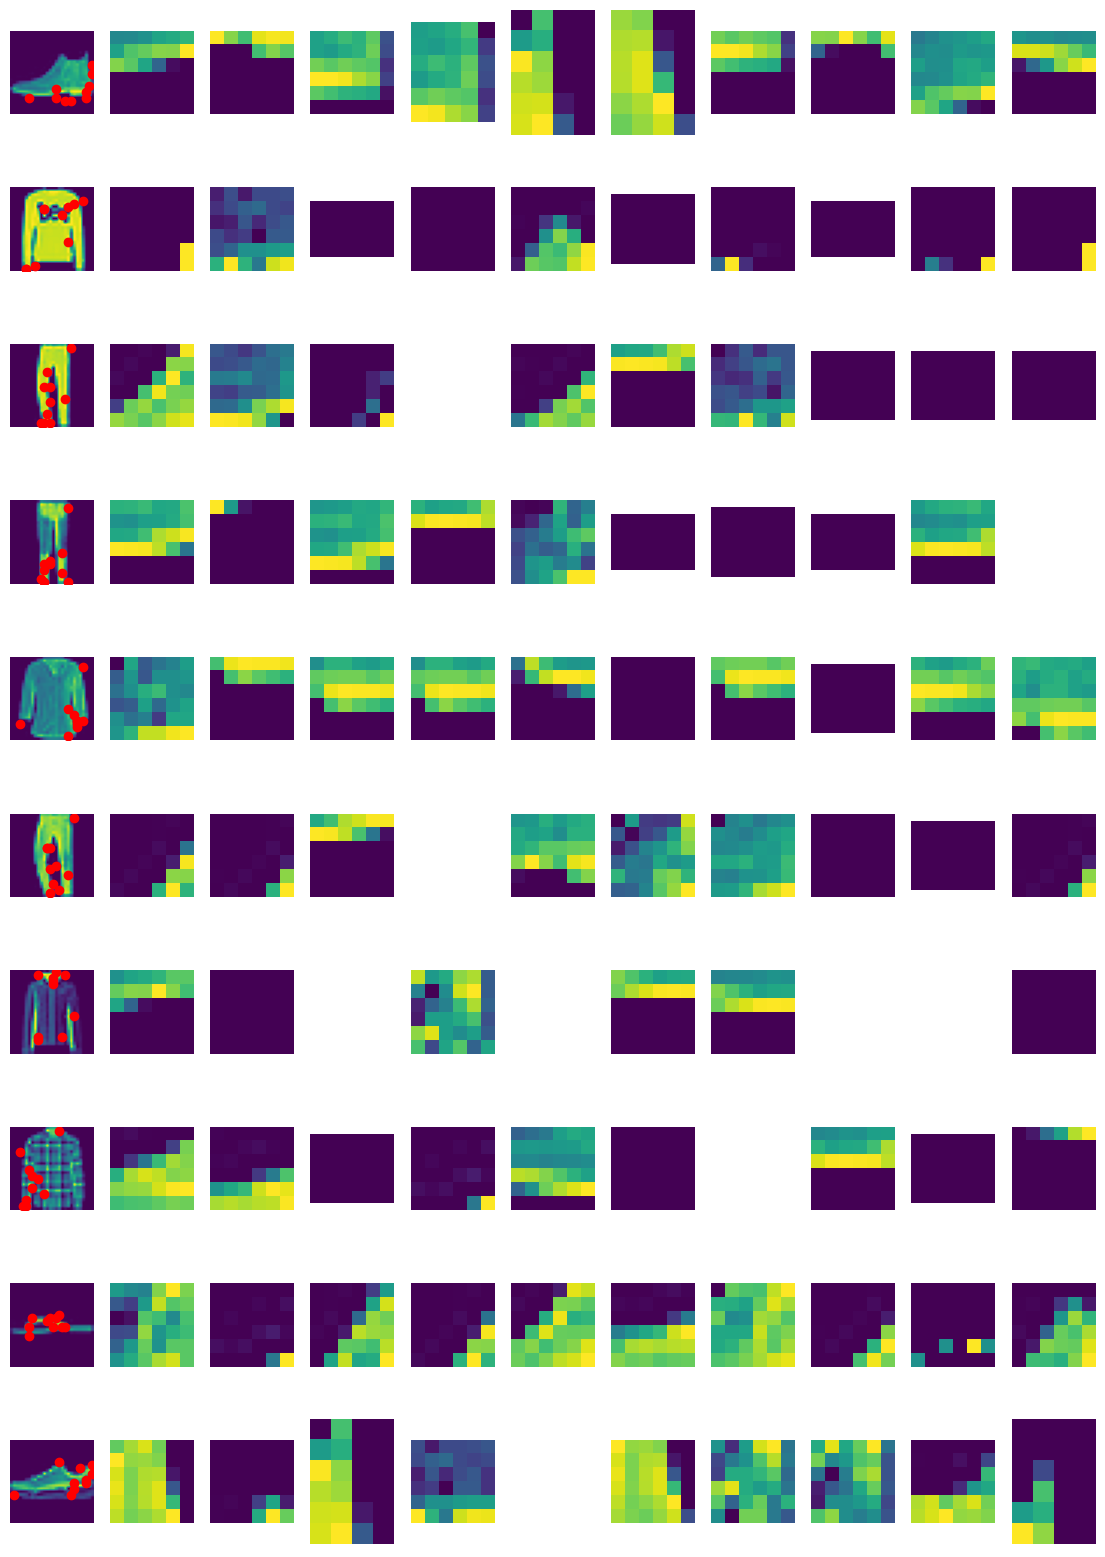

In [52]:
max_activation_part_multi(X_test[:10], model.layers[0])